**DATA SCI 3ML3 - FINAL PROJECT**

All work completed by Nicholas Zajkeskovic.

In [1]:
from glob import glob

Firstly, we need to read in all training data.

In [2]:
train_dataset = 'dataset/training/' 

In [3]:
glioma = glob(train_dataset + '/glioma_tumor/*.jpg')
meningioma = glob(train_dataset + '/meningioma_tumor/*.jpg')
pituitary = glob(train_dataset + '/pituitary_tumor/*.jpg')
no_tumor = glob(train_dataset + '/no_tumor/*.jpg')

We now need to preprocess images within each dataset and label them according to their classification.

In [4]:
x = [] # images
y = [] # labels for the images

In [5]:
import cv2
import numpy as np

In [6]:
for img in no_tumor:

    # read in the image
    img = cv2.imread(img)

    # convert image to grayscale
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # normalize the data
    img = img / 255

    # resize the image for uniformity
    img = cv2.resize(img, (256, 256))

    # compile the dataset of images
    x.append(img)

    # label each image accordingly and compile the dataset of labels
    y.append(0)

In [7]:
for img in glioma:
    img = cv2.imread(img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img / 255
    img = cv2.resize(img, (256, 256))
    x.append(img)
    y.append(1)

In [8]:
for img in meningioma:
    img = cv2.imread(img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img / 255
    img = cv2.resize(img, (256, 256))
    x.append(img)
    y.append(2)

In [9]:
for img in pituitary:
    img = cv2.imread(img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img / 255
    img = cv2.resize(img, (256, 256))
    x.append(img)
    y.append(3)

Convert the arrays into NumPy arrays so that we can use certain methods.

In [10]:
x = np.array(x)
y = np.array(y)

Since our data is ordered, we want to randomize it using scikit-learn.

In [11]:
from sklearn.utils import shuffle
x, y = shuffle(x, y, random_state=8)

Now with our data we can choose and create our model.

In [12]:
import tensorflow as tf

In [13]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(256, 256)),
    tf.keras.layers.Dense(128, activation='softmax')
])

In [14]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy() , 
              optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=0.001), 
              metrics=['accuracy'])

In order to test this model we need to get our training data and perform the same preprocessing on the data.

In [15]:
test_dataset = 'dataset/testing/'

In [16]:
test_x = []
test_y = []

In [17]:
for img in no_tumor:
    img = cv2.imread(img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img / 255
    img = cv2.resize(img, (256, 256))
    test_x.append(img)
    test_y.append(0)

In [18]:
for img in glioma:
    img = cv2.imread(img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img / 255
    img = cv2.resize(img, (256, 256))
    test_x.append(img)
    test_y.append(1)

In [19]:
for img in meningioma:
    img = cv2.imread(img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img / 255
    img = cv2.resize(img, (256, 256))
    test_x.append(img)
    test_y.append(2)

In [20]:
for img in pituitary:
    img = cv2.imread(img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img / 255
    img = cv2.resize(img, (256, 256))
    test_x.append(img)
    test_y.append(3)

In [21]:
test_x = np.array(test_x)
test_y = np.array(test_y)

In [22]:
from sklearn.utils import shuffle
test_x, test_y = shuffle(test_x, test_y, random_state=8)

In [23]:
history = model.fit(x, y, epochs=10, validation_data=(test_x, test_y))

Epoch 1/10
90/90 [==============================] - 15s 170ms/step - loss: 1.6880 - accuracy: 0.5488 - val_loss: 0.8954 - val_accuracy: 0.6972
Epoch 2/10
90/90 [==============================] - 2s 21ms/step - loss: 0.7769 - accuracy: 0.7279 - val_loss: 1.1409 - val_accuracy: 0.6247
Epoch 3/10
90/90 [==============================] - 2s 20ms/step - loss: 0.8635 - accuracy: 0.7303 - val_loss: 0.6460 - val_accuracy: 0.7516
Epoch 4/10
90/90 [==============================] - 2s 21ms/step - loss: 0.7564 - accuracy: 0.7488 - val_loss: 0.4473 - val_accuracy: 0.8352
Epoch 5/10
90/90 [==============================] - 2s 20ms/step - loss: 0.5594 - accuracy: 0.8084 - val_loss: 0.6539 - val_accuracy: 0.8038
Epoch 6/10
90/90 [==============================] - 2s 18ms/step - loss: 0.6914 - accuracy: 0.7976 - val_loss: 0.2141 - val_accuracy: 0.9303
Epoch 7/10
90/90 [==============================] - 2s 18ms/step - loss: 0.2973 - accuracy: 0.8976 - val_loss: 0.4614 - val_accuracy: 0.8052
Epoch 8/10


With this working model, we can evaluate the model and make our observations via the following.

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

90/90 [==============================] - 0s 4ms/step


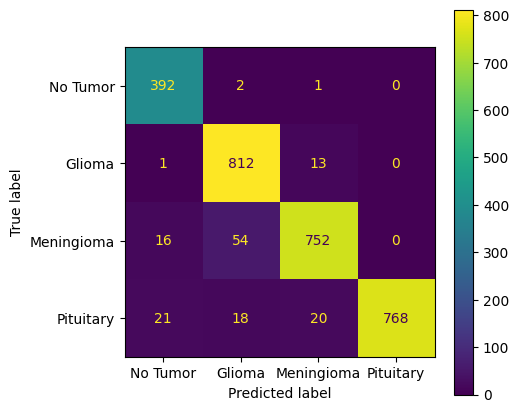

In [29]:
y_pred = model.predict(test_x)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(test_y, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Tumor', 'Glioma', 'Meningioma', 'Pituitary'])

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax)
plt.show()
